In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 


from jax import vmap, Array
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="0"

2025-02-06 14:05:11.664186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738850711.675665 3313240 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738850711.679262 3313240 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)

num_stars = 2

I0000 00:00:1738850713.018276 3313240 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 68 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


In [3]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

df = df_full[inputs+outputs]

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at all
teststar = df.sample(1)

df_test = df.sample(100000)

cluster_ages = np.random.normal(10000, 100, 100)
cluster_zini = np.random.normal(0.01, 0.0005, 100)
cluster_alphaMLT = np.random.normal(1.95, 0.005, 100)

In [4]:
normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

In [5]:
df_cluster = df[(df['numax'] < 300/3090)&(df['FeH'] > -0.1)&(df['FeH'] < 0.1)]
df_obs = df_cluster.groupby('age', as_index=False).sample(1).sample(num_stars)



In [6]:
df_obs = pd.DataFrame(columns = df_cluster.columns)
for i in range(num_stars):
    diff = (df_cluster['age'] - cluster_ages[i])**2 + (df_cluster['zini'] - cluster_zini[i])**2 + (df_cluster['alphaMLT'] - cluster_alphaMLT[i])**2
    df_obs.loc[i] = df_cluster.loc[diff.sort_values().index[0]]



In [67]:
def numpyro_model(uncs, obs = None):
    # Truncated distributions can be difficult to handle. Here I put them in to stop the emulator predicting outside
    # of the ranges it was trained on, but a beta distribution would be a better implementation

    # Note I use these priors to test my model on simulated stars - they are not data driven

    with numpyro.plate("star", len(uncs)):

            age = numpyro.sample('age', dist.TruncatedNormal(10000, 3000, low = 1000, high = 20000))

            massini = numpyro.sample('massini', dist.TruncatedNormal(1, 0.1, low = 0.7, high = 1.5)) 
    
            zini = numpyro.sample('zini', dist.TruncatedNormal(0.014, 0.01, low = 0, high = 0.06))

            yini = numpyro.sample('yini', dist.TruncatedNormal(0.28, 0.1, low = 0.22, high = 0.35))
    
            alphaMLT = numpyro.sample('alphaMLT', dist.TruncatedNormal(1.95, 0.1, low = 1.5, high = 2.3))

            

            eta = numpyro.sample('eta', dist.TruncatedNormal(0.15, 0.1, low = 0, high = 0.3))

            alphaFe = numpyro.sample('alphaFe', dist.TruncatedNormal(0.2, 0.3, low = -0.2, high =0.6))

            params_norm = jnp.stack([massini, zini, yini, alphaMLT, age, eta, alphaFe], axis = -1)

            pred_norm = model_outputs(params_norm)


    y = numpyro.sample("y", dist.Normal(pred_norm, uncs), obs=obs)

# Prior Predictive Test

In [12]:
jnp.array(df_obs[outputs])[0], df_obs[outputs]

(Array([-4.1551035e-02,  3.3870148e+01,  4.5745249e+03,  1.3070246e-02,
         3.4337122e-02], dtype=float32),
         FeH      LPhot         Teff     numax    dnuSer
 0 -0.041551  33.870150  4574.524937  0.013070  0.034337
 1  0.003694  81.110833  4356.362767  0.004861  0.015754)

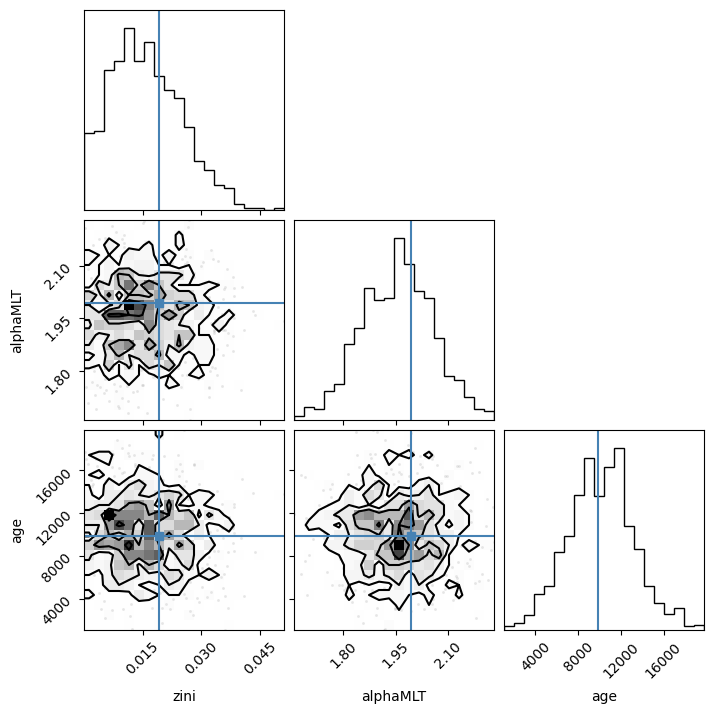

In [13]:
#fig = corner.corner(data, group="prior", var_names=['mu_zini', 'std_zini', 'mu_alphaMLT', 'std_alphaMLT', 'mu_age', 'std_age'], \
#                    truths = [np.mean(df_obs['zini']), np.std(df_obs['zini']), np.mean(df_obs['alphaMLT']), \
#                              np.std(df_obs['alphaMLT']), np.mean(df_obs['age']), np.std(df_obs['age'])])

fig = corner.corner(data, group="prior", var_names=['zini', 'alphaMLT', 'age',], \
                    truths = [np.mean(df_obs['zini']), np.mean(df_obs['alphaMLT']), np.mean(df_obs['age']), ], coords ={'star':0})

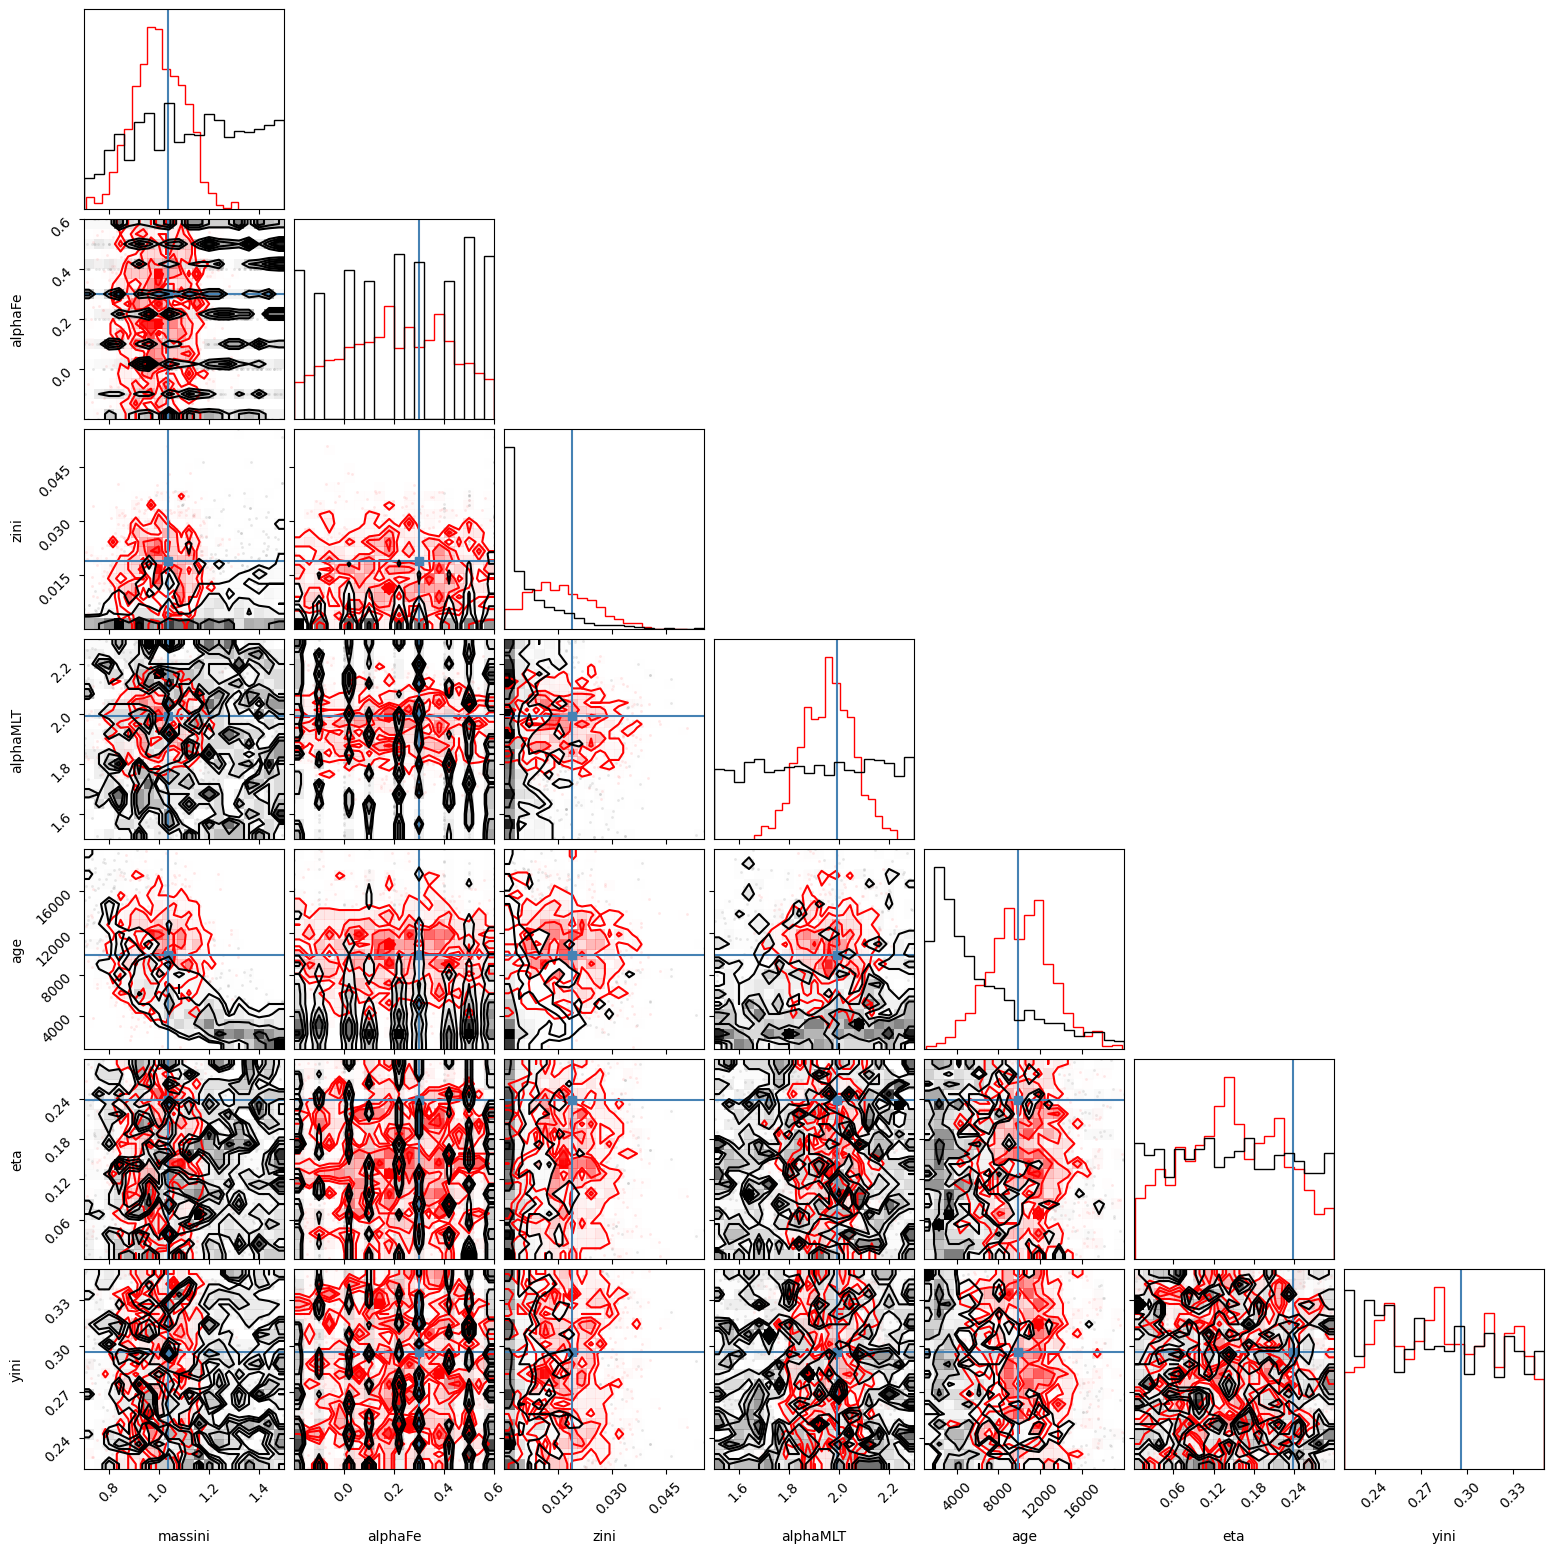

In [65]:
df_test = df.sample(1000)

fig = corner.corner(data, group="prior", var_names=['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini'], \
                    truths = [np.mean(df_obs['massini']), np.mean(df_obs['alphaFe']), np.mean(df_obs['zini']), np.mean(df_obs['alphaMLT']), \
                              np.mean(df_obs['age']), np.mean(df_obs['eta']), np.mean(df_obs['yini'])], coords = {'star':0}, color = 'red')

corner.corner(df_test[['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini']], fig = fig, zorder = 0, alpha = 0.5)
plt.savefig('../figs/single-star-example-priors.png', bbox_inches = 'tight')
plt.show()

In [66]:
pwd

'/home/hatte/M4/notebooks'

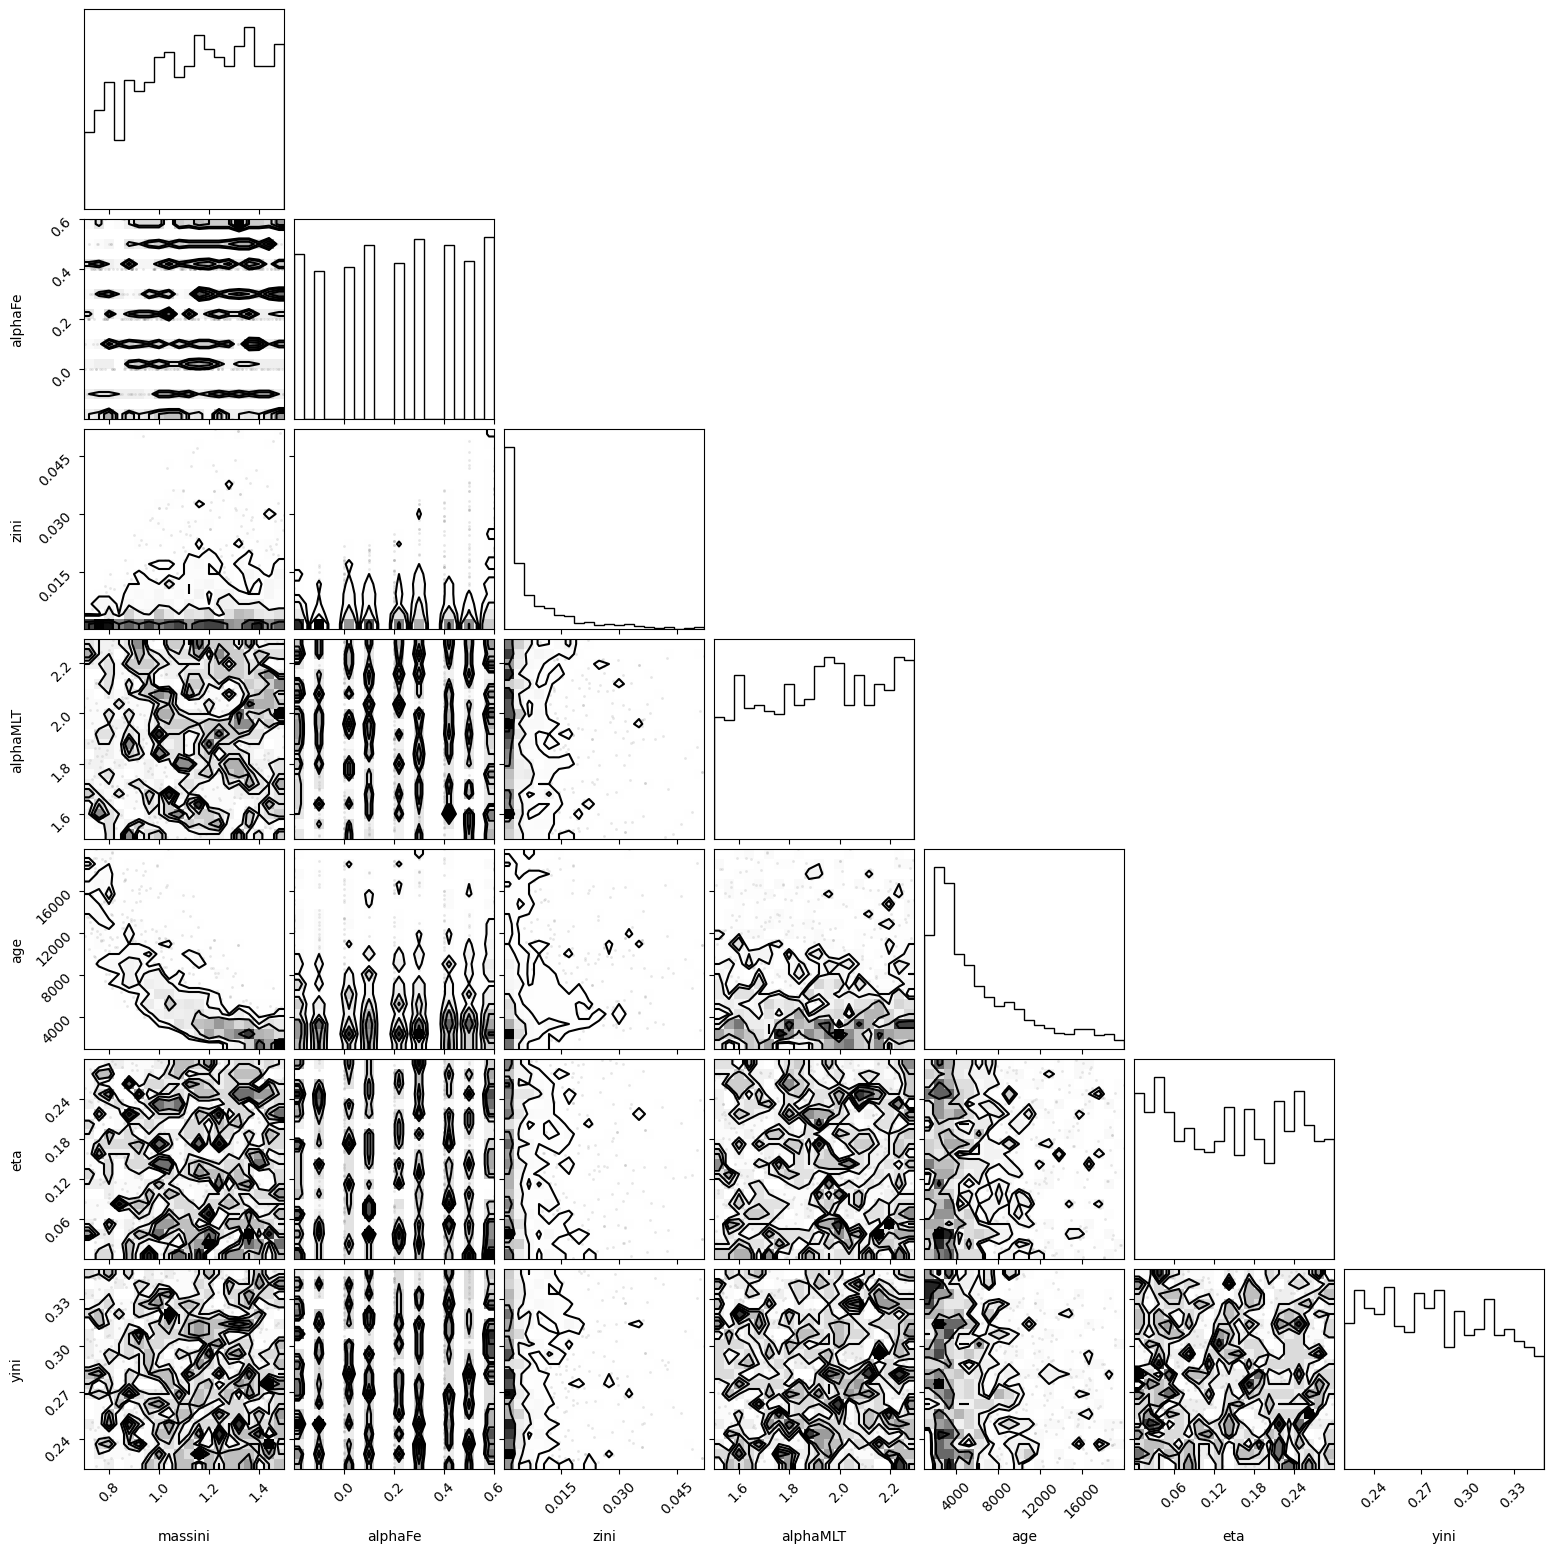

In [15]:
corner.corner(df_test[['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini']],zorder = 0, alpha = 0.5)
plt.show()

And now for the observables;

# Now to Fit

In [16]:
num_warmup, num_samples = 1000, 8000

num_chains = 2

sampler = NUTS(numpyro_model, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_median) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

/tmp/ipykernel_3313240/2926949301.py:7: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)


In [17]:
mcmc.run(jax.random.PRNGKey(0),  uncs=uncert, obs=jnp.array(df_obs[outputs]))

mcmc.print_summary()

sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [11:11<00:00, 13.41it/s, 1023 steps of size 5.84e-04. acc. prob=0.85]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
     age[0]  10331.34   2342.82  10311.43   6333.21  14167.45    163.38      1.01
     age[1]  10180.73   2376.84  10056.30   6373.29  14011.31    204.25      1.00
 alphaFe[0]      0.22      0.17      0.22     -0.07      0.48    136.19      1.03
 alphaFe[1]      0.17      0.18      0.17     -0.14      0.46     21.05      1.08
alphaMLT[0]      1.94      0.09      1.94      1.79      2.10    250.68      1.00
alphaMLT[1]      1.95      0.09      1.95      1.80      2.10    226.93      1.01
     eta[0]      0.15      0.07      0.15      0.03      0.26    307.01      1.00
     eta[1]      0.15      0.07      0.15      0.04      0.28    670.66      1.01
 massini[0]      1.01      0.07      1.01      0.89      1.12    154.26      1.00
 massini[1]      1.03      0.08      1.03      0.91      1.16    108.24      1.02
    yini[0]      0.29      0.03      0.30      0.25      0.35    158.74      1.06
    yini[1]    

In [150]:
df_obs

,massini,zini,yini,alphaMLT,age,eta,alphaFe,FeH,logLPhot,Teff,numax,dnuSer
0,1.066,0.017209,0.274518,1.984424,9900.350473,0.211285,0.2,0.003694,1.552493,4572.403328,0.013119,0.033970
1,0.981,0.012249,0.294379,2.108105,9978.537989,0.275793,0.1,-0.063554,1.632476,4709.822999,0.011111,0.030917


Now we do a posterior predictive check to make sure everything makes sense

Plotting with arviz

In [18]:
posterior = mcmc.get_samples(group_by_chain=True)
sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))
posterior_predictive = Predictive(numpyro_model, posterior_samples=posterior, parallel=True, return_sites=["y"], batch_ndims=2)
y = posterior_predictive(key,  obs=None, \
                         uncs=uncert, )["y"]

for i, key in enumerate(model_outputs.outputs):
    posterior[key] = y[..., i]

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)
data

Inference data with groups:
	> posterior
	> sample_stats
	> prior

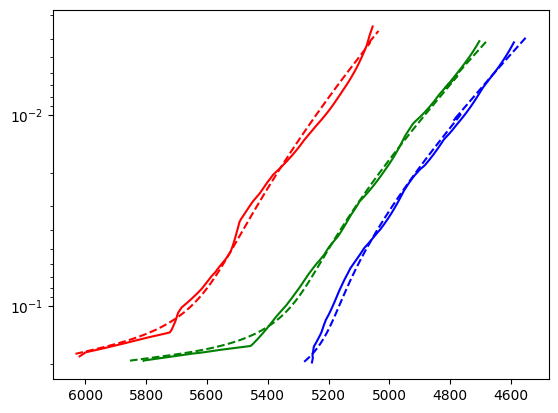

In [19]:
colors = ['red', 'green', 'blue']
for j in range(3):

    star = df.sample(1)
    track_star = df.merge(star[['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']])
    testerdf = pd.DataFrame(columns = inputs)
    testerdf['age'] = np.linspace(np.min(track_star['age']), np.max(track_star['age']), 1000)

    for i in ['massini', 'zini', 'yini', 'alphaMLT', 'eta', 'alphaFe']:
        testerdf[i] = star[i].values[0]


    testerout = model_outputs(np.array(testerdf))

    plt.plot(track_star['Teff'], track_star['numax'], color = colors[j], linestyle= '--')
    plt.plot(testerout.T[2], testerout.T[3], color = colors[j])
plt.semilogy()
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()

array([[<Axes: title={'center': 'massini'}>,
        <Axes: title={'center': 'massini'}>],
       [<Axes: title={'center': 'zini'}>,
        <Axes: title={'center': 'zini'}>],
       [<Axes: title={'center': 'yini'}>,
        <Axes: title={'center': 'yini'}>],
       [<Axes: title={'center': 'alphaMLT'}>,
        <Axes: title={'center': 'alphaMLT'}>],
       [<Axes: title={'center': 'age'}>, <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'eta'}>, <Axes: title={'center': 'eta'}>],
       [<Axes: title={'center': 'alphaFe'}>,
        <Axes: title={'center': 'alphaFe'}>]], dtype=object)

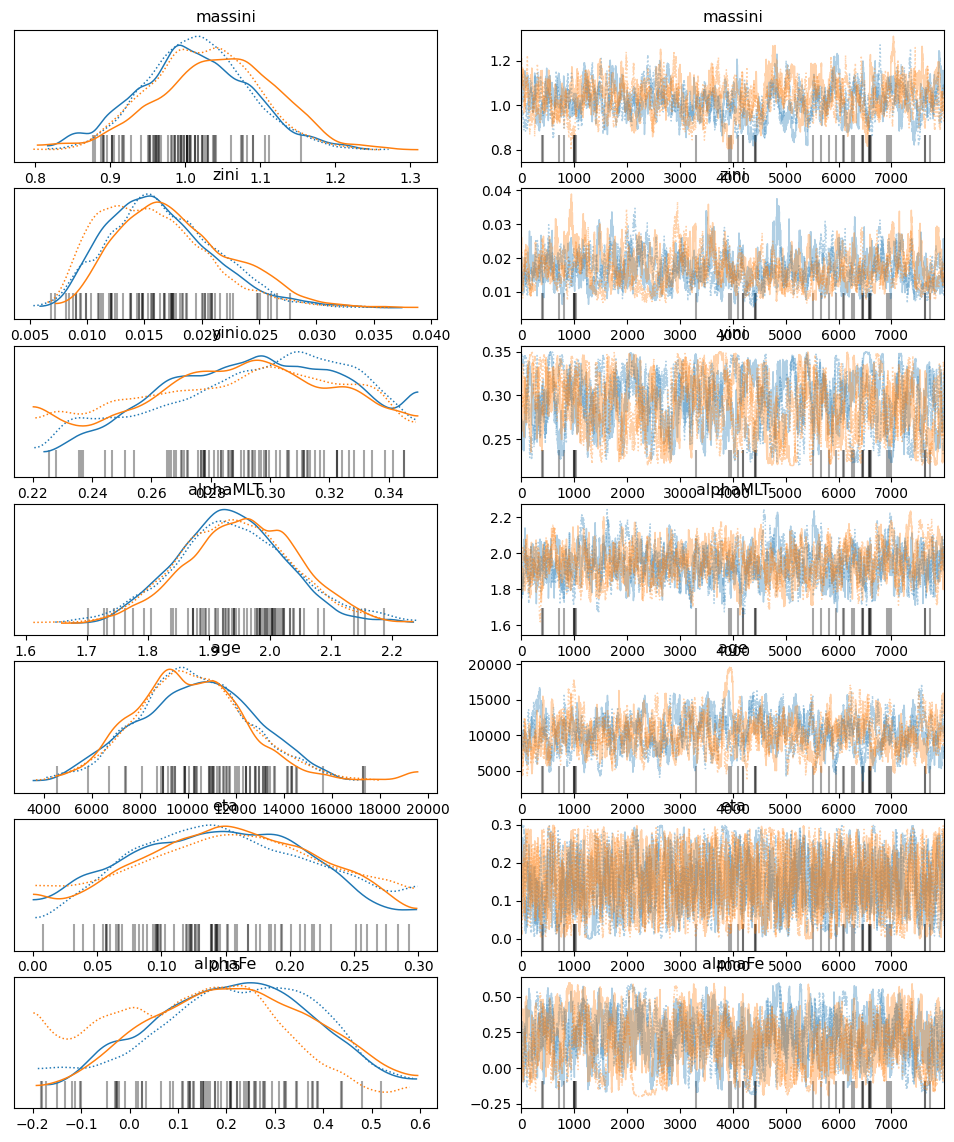

In [20]:
stat_funcs = {
    "q_16": lambda x: np.quantile(x, .16),
    "q_50": lambda x: np.quantile(x, .5),
    "q_84": lambda x: np.quantile(x, .84),
}

az.summary(data, fmt="xarray", stat_funcs=stat_funcs)
az.plot_trace(data, var_names=model_outputs.inputs)

In [21]:
np.array(df_obs[outputs]), df_obs[outputs]

(array([[-4.15510350e-02,  3.38701496e+01,  4.57452494e+03,
          1.30702459e-02,  3.43371206e-02],
        [ 3.69381344e-03,  8.11108332e+01,  4.35636277e+03,
          4.86066654e-03,  1.57537010e-02]]),
         FeH      LPhot         Teff     numax    dnuSer
 0 -0.041551  33.870150  4574.524937  0.013070  0.034337
 1  0.003694  81.110833  4356.362767  0.004861  0.015754)

In [46]:
truths_inputs = [np.mean(df_obs[i]) for i in model_outputs.inputs]

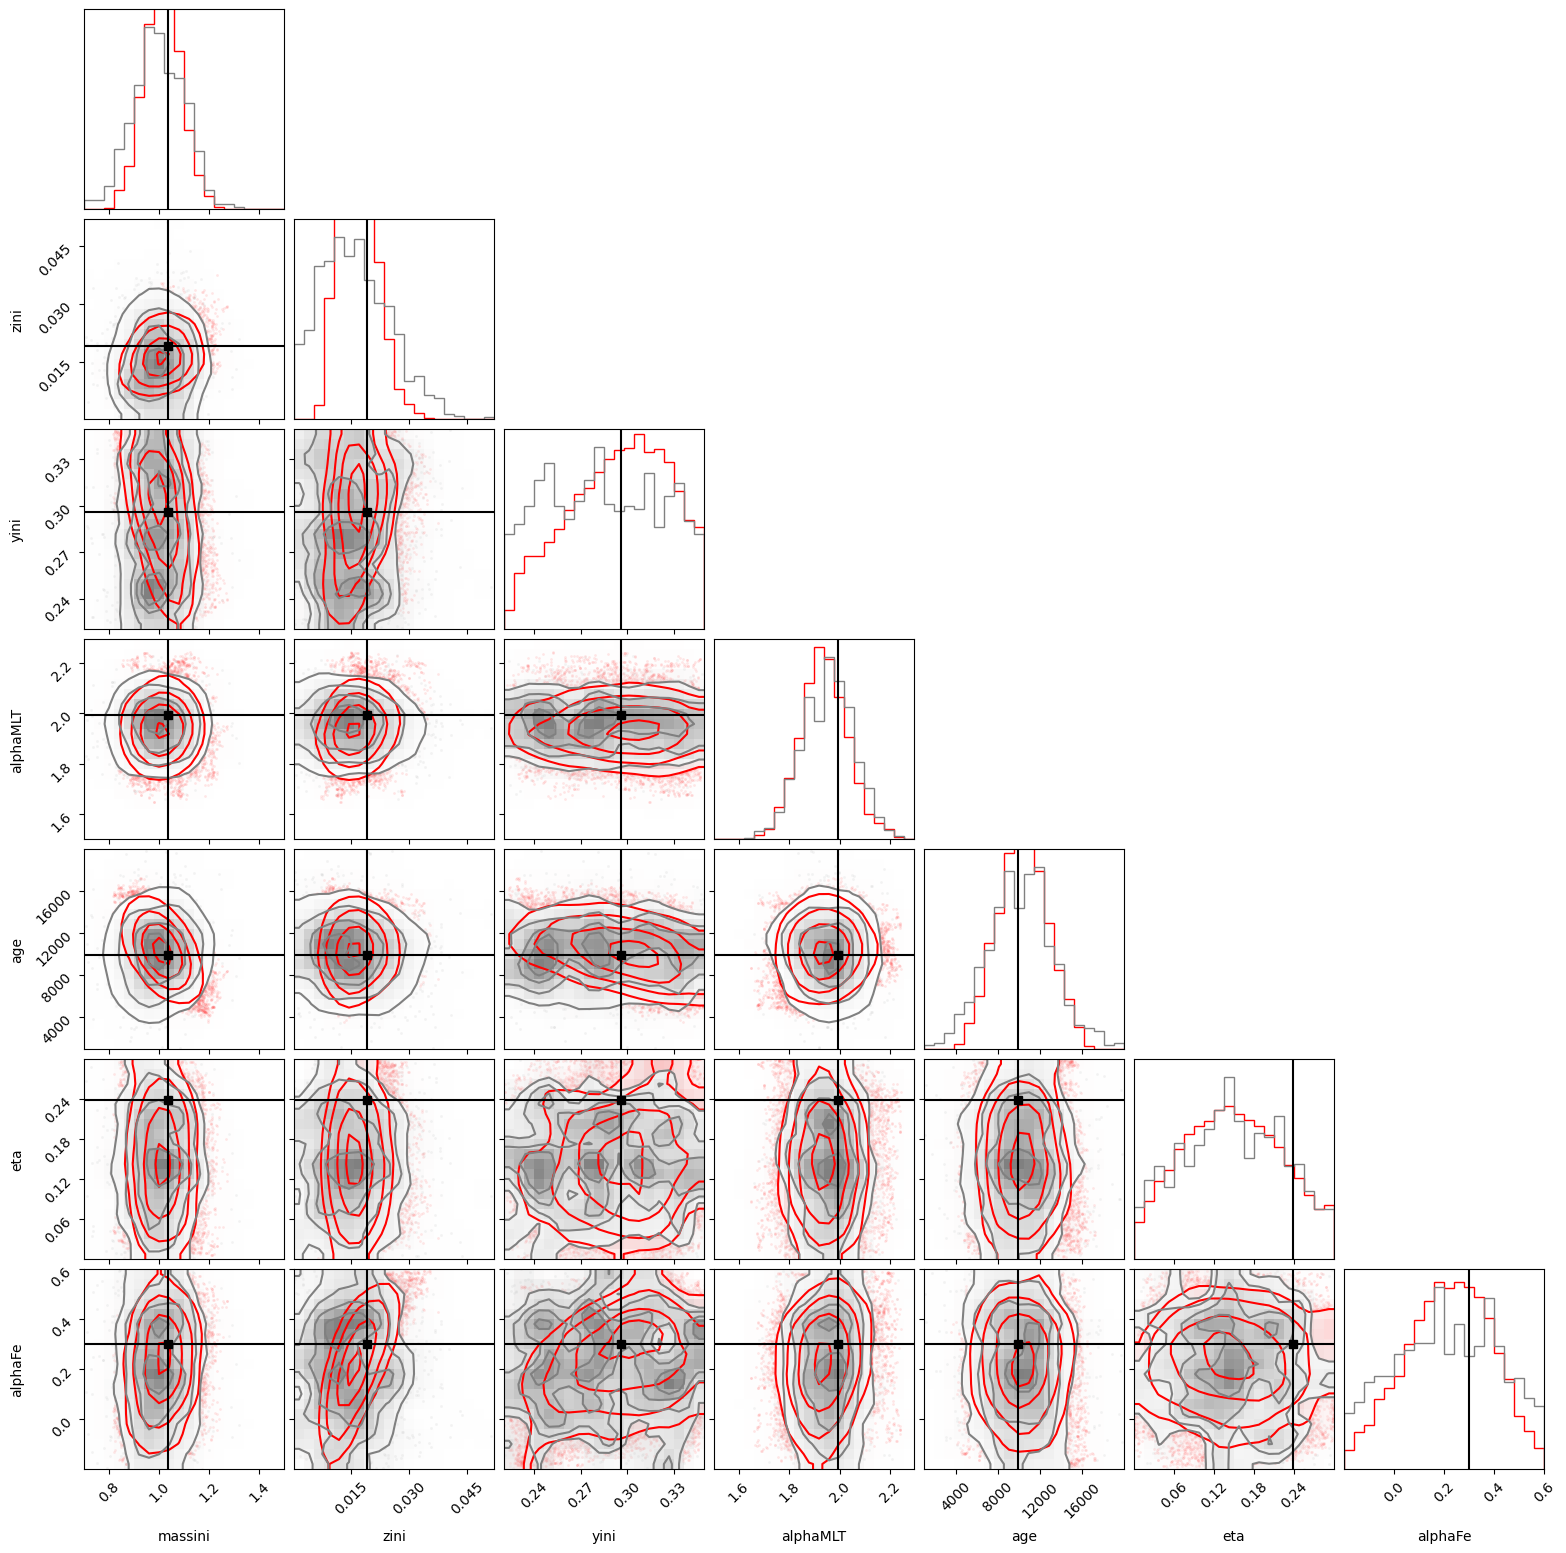

In [63]:
ranges = [(np.min(df_test[i].values), np.max(df_test[i].values)) for i in model_outputs.inputs]
fig = corner.corner(data, group="posterior", var_names = model_outputs.inputs, coords = {'star':0}, color = 'red', range = ranges, zorder = 1, weights = np.ones(16000)/16000, smooth = True, plot_datapoints = True)
#corner.corner(df_test[model_outputs.inputs],zorder = 0, alpha = 0.5, fig = fig)
corner.corner(data, group="prior", var_names=model_outputs.inputs, \
                    truths = truths_inputs, coords = {'star':0}, color = 'grey', fig = fig, range = ranges, zorder = 0, \
                      weights=np.ones(1000)/1000, truth_color = 'black', smooth = True,)
fig.savefig('../figs/single-star-model-test.png', bbox_inches = 'tight', dpi = 150)
plt.show()


In [80]:
pyro_data['posterior']['massini']

<xarray.DataArray 'massini' (chain: 2, draw: 100, star: 1)> Size: 800B
array([[[0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
        [0.48518836],
...
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373],
        [0.55217373]]], dtype=float32)
Coordinates:
  * chain    (chain) int64 16B 0 1
  * draw     (draw) int64 800B 0 1 2 3 4 5 6 7 8 ... 91 92 93 94 95 96 97 98 99
  * star     (star) int64 8B 0

In [81]:
pyro_data['prior']['massini']

<xarray.DataArray 'massini' (chain: 1, draw: 1000, massini_dim_0: 1)> Size: 4kB
array([[[2.91819155e-01],
        [8.01607013e-01],
        [5.94765365e-01],
        [4.98237312e-02],
        [3.68365943e-02],
        [1.73886195e-01],
        [4.05853420e-01],
        [3.57232839e-01],
        [9.63334858e-01],
        [1.18061095e-01],
        [4.27595913e-01],
        [6.10919058e-01],
        [7.25333810e-01],
        [2.72091329e-01],
        [4.55610275e-01],
        [1.42774284e-01],
        [4.15347278e-01],
        [2.91000843e-01],
        [1.33129135e-01],
        [3.67990911e-01],
...
        [4.21103686e-01],
        [1.57884941e-01],
        [5.51209211e-01],
        [5.43135405e-03],
        [5.50280392e-01],
        [3.61363888e-02],
        [4.06461239e-01],
        [2.74014533e-01],
        [5.44702947e-01],
        [5.21203101e-01],
        [1.69838309e-01],
        [3.45304102e-01],
        [1.13188624e-02],
        [9.34962928e-02],
        [9.37851846e-01],
        [8.13201368e-01],
        [1.22966051e-01],
        [1.52739257e-01],
        [5.69649935e-02],
        [2.79875219e-01]]], dtype=float32)
Coordinates:
  * chain          (chain) int64 8B 0
  * draw           (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * massini_dim_0  (massini_dim_0) int64 8B 0

In [43]:
norm_phys_unc

Array([[0.09021765, 0.09398817, 0.04878649, 0.00026533, 0.00051328],
       [0.09021765, 0.09398817, 0.04878649, 0.00026533, 0.00051328]],      dtype=float32)